# 18 · Testing  (`18_nonvlm_te`)

Grade any card image with the trained model, plus full diagnostics.

| Class | Use |
|---|---|
| **`GradePredictor`** | `predict` / `report` (one-shot: prediction + boundaries + bars + feature table) / `manual` (interactive slider correction) |
| **`NewCardTest`** | unified new-card grading — `t.run(grade=7)` detects → extracts → predicts → renders **all** details in one shot |

Detector = **Model C (Roboflow seg)** — the production outer-boundary method validated in `18_nonvlm_boundaries`.

In [1]:
%matplotlib inline
import os, sys, json, warnings, glob
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '../backend')
from dotenv import load_dotenv
load_dotenv('../.env.local', override=True)
import nonvlm_cv as N    # light import; detectors (Roboflow seg / local YOLO) load lazily on first use

BASE   = Path('feature_extraction_dataset')
MODELS = Path('models')
print('Models:')
for f in sorted(MODELS.glob('*.pkl')):
    print(f'  {f.name}  ({f.stat().st_size//1024}KB)')

Models:
  cv_xgb.pkl  (2615KB)
  cv_xgb_processed.pkl  (2507KB)
  cv_xgb_raw.pkl  (2469KB)
  haiku_xgb.pkl  (2595KB)


## GradePredictor

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GradePredictor — all-in-one: predict · report (one-shot diagnostics) · manual
#   gp = GradePredictor("models/cv_xgb_raw.pkl", feature_source="cv")  # raw=best
#   gp.report(card, true_psa=7)   # ONE SHOT: prediction + boundaries + bars + feature table
#   gp.manual(card, true_psa=7)   # interactive slider correction (+ live re-prediction)
#   gp.predict(card)              # prediction dict
# ════════════════════════════════════════════════════════════════════════════
import io, ipywidgets as Wd
from IPython.display import display
from matplotlib.patches import Rectangle, Polygon
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

class GradePredictor:
    """Predict a PSA grading tier from a card image, with built-in diagnostics."""
    SEV_COLORS = ["#ffffff","#fff9c4","#ffe0b2","#ff8a65","#e53935"]   # none→heavy
    CYAN, BLUE = "#22d3ee", "#1e90ff"
    _TIER_OF   = {5:0,6:0,7:1,8:1,9:2,10:3}
    _BGR       = {"cyan":(238,211,34),"blue":(255,144,30),"red":(86,87,228)}
    LABELS_CSV = Path("diag")/"manual_centering_labels.csv"
    RECO = {0:"Don't submit — not worth the fee", 1:"Consider — depends on card value",
            2:"Submit — PSA 9 adds significant value", 3:"Submit — PSA 10 Gem Mint, max premium"}

    def __init__(self, model_path, feature_source="cache", cache_csv=None,
                 api_key=None, detector="seg"):
        assert feature_source in ("cache","cv","haiku")
        b = joblib.load(model_path)
        self.model_, self.feature_cols_ = b["model"], b["feature_cols"]
        self.tier_labels_, self.tier_short_, self.n_tiers_ = b["tier_labels"], b["tier_short"], b["n_tiers"]
        self.tier_colors_ = ["#e45756","#f28e2b","#4c78a8","#54a24b"]
        self.source_   = b["source"]            # model's training feature source ("cv"/"haiku")
        self.feat_src_ = feature_source         # how predict()/show() extract features
        self.detector  = detector               # detector for analyze/report/manual
        self.api_key_  = api_key or os.environ.get("ANTHROPIC_API_KEY","")
        self.cache_    = {}
        if cache_csv and os.path.exists(cache_csv):
            for _, row in pd.read_csv(cache_csv).iterrows():
                self.cache_[os.path.abspath(str(row.get("path","")))] = row.to_dict()
            print(f"  cache: {len(self.cache_)} entries from {Path(cache_csv).name}")
        print(f"  model: {self.source_.upper()}  source: {feature_source}  features: {len(self.feature_cols_)}")

    # ── feature extraction for predict()/show() (respects feature_source) ────
    def _extract_features(self, image_path):
        abs_path = os.path.abspath(image_path)
        if self.feat_src_ == "cache":
            feat = self.cache_.get(abs_path)
            if feat is None:
                bn = os.path.basename(image_path)
                feat = next((v for k,v in self.cache_.items() if os.path.basename(k)==bn), None)
            if feat is None:
                raise ValueError(f"Not in cache: {os.path.basename(image_path)} "
                                 f"({len(self.cache_)} entries checked).")
            return feat
        img = cv2.imread(image_path)
        if img is None: raise FileNotFoundError(f"Cannot read: {image_path}")
        det = N.detect_and_warp(img, detector=self.detector, out_size=N.CV_WARP_SIZE)
        cr  = N.compute_centering_hybrid(det["warped"], det["cb"])["content_region"]
        return self._feat_from(det, cr)[0]

    def _to_X(self, feat):
        return [[float(feat.get(c, 0.0)) for c in self.feature_cols_]]

    # ── shared: features + prediction for a given inner boundary cr ──────────
    def _feat_from(self, det, cr):
        """Return (feature_dict, cv_cond) for a given content_region cr."""
        geo = N._centering_from_cr(det["cb"], cr)
        lr = int(geo["left_right"].split("/")[0]); tb = int(geo["top_bottom"].split("/")[0])
        cv_cond, cv_raw = N.cv_extract_conditions(det, cr=cr)
        if self.source_ == "raw":            # raw-measurement model (m.*/mag.*/conf.*)
            feat = N.raw_to_vector(cv_cond, cv_raw)
        elif self.source_ in ("cv", "processed"):   # processed-severity model (cv.*)
            feat = {f"cv.{k}": v for k,v in N.features_to_vector(cv_cond).items()}
        else:   # haiku/cache model: defect features fixed; only centering depends on cr
            key = os.path.abspath(det.get("path","")) if det.get("path") else None
            feat = {k:v for k,v in (self.cache_.get(key) or {}).items() if isinstance(k,str)}
        feat["cen.lr_deviation"] = abs(lr-50); feat["cen.tb_deviation"] = abs(tb-50)
        return feat, cv_cond

    def analyze(self, image_path, cr=None, det=None):
        """Detect → centering → CV features → predict. Returns a result dict."""
        if det is None:
            det = N.detect_and_warp(cv2.imread(image_path), detector=self.detector, out_size=N.CV_WARP_SIZE)
        det["path"] = os.path.abspath(image_path)
        cen = N.compute_centering_hybrid(det["warped"], det["cb"])
        manual = cr is not None
        cr = cr if manual else cen["content_region"]
        # display geometry reflects the boundary ACTUALLY used (auto or manual override)
        geo = N._centering_from_cr(det["cb"], cr)
        cen = {**cen, "left_right": geo["left_right"], "top_bottom": geo["top_bottom"],
               "score": geo["score"], "content_region": cr}
        if manual:
            cen["reliable"] = True
            if "(manual)" not in cen.get("border_type",""):
                cen["border_type"] = f"{cen.get('border_type','')} (manual)".strip()
        feat, cv_cond = self._feat_from(det, cr)
        proba = self.model_.predict_proba(self._to_X(feat))[0]; idx = int(proba.argmax())
        return dict(path=image_path, det=det, cen=cen, cr=cr, cv_cond=cv_cond,
                    proba=proba, idx=idx, tier=self.tier_labels_[idx], conf=float(proba[idx]))

    # ── prediction API ───────────────────────────────────────────────────────
    def predict(self, image_path):
        feat  = self._extract_features(image_path)
        proba = self.model_.predict_proba(self._to_X(feat))[0]; idx = int(proba.argmax())
        return {"tier": self.tier_labels_[idx], "tier_idx": idx, "confidence": round(float(proba[idx]),3),
                "probabilities": {s: round(float(p),3) for s,p in zip(self.tier_short_, proba)},
                "recommendation": self.RECO[idx]}

    def predict_batch(self, image_paths, psa_grades=None):
        rows=[]
        for i,p in enumerate(image_paths):
            try:
                r=self.predict(p); r["file"]=os.path.basename(p)
                if psa_grades: r["true_psa"]=psa_grades[i]
            except Exception as e: r={"file":os.path.basename(p),"error":str(e)[:80]}
            rows.append(r)
        return pd.DataFrame(rows)

    # ── drawing helpers ───────────────────────────────────────────────────────
    def _draw_bars(self, ax, proba, idx, true_psa):
        cols=[self.tier_colors_[i] if i==idx else "#cdd7e1" for i in range(len(proba))]
        ax.bar(range(len(proba)),proba,color=cols,edgecolor="white")
        ax.set_xticks(range(len(proba))); ax.set_xticklabels(self.tier_short_,fontsize=10)
        ax.set_ylim(0,1.0); ax.set_ylabel("P(tier)")
        for i,p in enumerate(proba):
            if p>0.015: ax.text(i,p+0.02,f"{p:.0%}",ha="center",fontsize=10,fontweight="bold")
        if true_psa is not None and int(true_psa) in self._TIER_OF:
            ax.axvline(self._TIER_OF[int(true_psa)],color="k",ls="--",lw=1.4,alpha=0.6)
            ax.text(self._TIER_OF[int(true_psa)],1.0," true",fontsize=8,va="top")
        ax.set_title("tier probability",fontsize=9)

    def _draw_boundaries(self, ax, det, cen, cr):
        wp=det["warped"]; h,w=wp.shape[:2]; rgb=cv2.cvtColor(wp,cv2.COLOR_BGR2RGB).copy(); cw=det.get("cw")
        if cw is not None and len(cw)>2:
            cwpx=(np.asarray(cw)*[w,h]).astype(np.int32); m=np.zeros((h,w),np.uint8); cv2.fillPoly(m,[cwpx],255); rgb[m==0]=0
        ax.imshow(rgb); ax.axis("off")
        if cw is not None and len(cw)>2:
            ax.add_patch(Polygon(np.asarray(cw)*[w,h],closed=True,fill=False,edgecolor=self.CYAN,lw=2))
        if cw is not None and len(cw)>2:
            ax.get_children()  # outer drawn above (label it via proxy below)
        for c2,col,ls,lw,lab in [(cen.get("_cr_analytical"),self.CYAN,"--",1.0,"analytical"),
                                 (cen.get("_cr_color_vote"),"orange",":",1.0,"color-vote"),
                                 (cr,self.BLUE,"-",2.5,"inner (reconciled)")]:
            if c2: ax.add_patch(Rectangle((c2["x1"]*w,c2["y1"]*h),(c2["x2"]-c2["x1"])*w,(c2["y2"]-c2["y1"])*h,
                                          fill=False,edgecolor=col,ls=ls,lw=lw,label=lab))
        from matplotlib.lines import Line2D
        handles=[Line2D([0],[0],color=self.CYAN,lw=2,label="outer (Model C)"),
                 Line2D([0],[0],color=self.CYAN,lw=1,ls="--",label="analytical"),
                 Line2D([0],[0],color="orange",lw=1,ls=":",label="color-vote"),
                 Line2D([0],[0],color=self.BLUE,lw=2.5,label="inner (reconciled)")]
        ax.legend(handles=handles,fontsize=7,loc="lower right",framealpha=0.85)
        ax.set_title("cyan=outer · blue=inner · dashed=analytical · dotted=color-vote",fontsize=8)

    def _draw_table(self, cv_cond, cen):
        cmap=ListedColormap(self.SEV_COLORS); norm=BoundaryNorm([0,1,2,3,4,5],cmap.N)
        sev=lambda node,d:int(N._sev(node.get(d,0)))
        cor,edg,srf=cv_cond["corners"],cv_cond["edges"],cv_cond["surface"]
        cM=np.array([[sev(cor[l],d) for d in N.CORNER_DEFECTS] for l in N.CORNER_LOCS])
        eM=np.array([[sev(edg[l],d) for d in N.EDGE_DEFECTS] for l in N.EDGE_LOCS])
        sM=np.array([[sev(srf,d) for d in N.SURFACE_DEFECTS]])
        fig=plt.figure(figsize=(8.5,7)); gs=fig.add_gridspec(3,1,height_ratios=[4,4,1.4],hspace=0.55)
        def heat(ax,M,rows,colsL,title):
            ax.imshow(M,cmap=cmap,norm=norm,aspect="auto")
            ax.set_xticks(range(len(colsL))); ax.set_xticklabels(colsL,fontsize=8,rotation=25,ha="right")
            ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows,fontsize=8)
            for i in range(len(rows)):
                for j in range(len(colsL)):
                    v=int(M[i,j]); ax.text(j,i,N.SEV_NAME[v] if v>0 else "·",ha="center",va="center",
                                           fontsize=7.5,color="white" if v>=3 else "#333",fontweight="bold" if v>=2 else "normal")
            ax.set_title(title,fontsize=9,loc="left")
            for s in ax.spines.values(): s.set_visible(False)
            ax.tick_params(length=0)
        heat(fig.add_subplot(gs[0]),cM,[l.replace("_"," ") for l in N.CORNER_LOCS],N.CORNER_DEFECTS,"Corners")
        heat(fig.add_subplot(gs[1]),eM,N.EDGE_LOCS,N.EDGE_DEFECTS,"Edges")
        heat(fig.add_subplot(gs[2]),sM,["surface"],N.SURFACE_DEFECTS,"Surface")
        lr=int(cen["left_right"].split("/")[0]); tb=int(cen["top_bottom"].split("/")[0])
        fig.suptitle(f"CV severities (white=none → red=heavy)   ·   centering L/R {cen['left_right']} "
                     f"(dev {abs(lr-50)})   T/B {cen['top_bottom']} (dev {abs(tb-50)})",fontsize=9,y=0.99)
        plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

    # ── render an already-computed analyze() result (no re-detection) ────────
    def render(self, r, true_psa=None):
        cen=r["cen"]; name=os.path.basename(r["path"]); tt=f"  (true PSA {true_psa})" if true_psa else ""
        print(f"{name}")
        print(f"  centering  L/R {cen['left_right']}  T/B {cen['top_bottom']}  "
              f"score {cen['score']:.0f}/10  border {cen['border_type']}  reliable {cen['reliable']}")
        print(f"  detector {r['det'].get('detector')}  seg_conf {float(r['det'].get('seg_conf',0)):.0%}")
        print(f"  PREDICTION → {r['tier']}   ({r['conf']:.0%}){tt}   [model: {self.source_}]")
        fig=plt.figure(figsize=(13,7)); gs=fig.add_gridspec(1,2,width_ratios=[1,1.05])
        self._draw_boundaries(fig.add_subplot(gs[0]), r["det"], cen, r["cr"])
        self._draw_bars(fig.add_subplot(gs[1]), r["proba"], r["idx"], true_psa)
        plt.suptitle(f"{name}  →  {r['tier']}  ({r['conf']:.0%})",fontsize=12)
        plt.tight_layout(); plt.show()
        self._draw_table(r["cv_cond"], cen)
        return r

    # ── ONE-SHOT report from an image path (detect → analyze → render) ───────
    def report(self, image_path, true_psa=None):
        return self.render(self.analyze(image_path), true_psa)

    # ── card + bars only (lightweight) ───────────────────────────────────────
    def show(self, image_path, true_psa=None):
        return self.report(image_path, true_psa=true_psa)

    # ── verifiable defect overlay: draw detections ON the pixels ─────────────
    @staticmethod
    def _place_edge(v, H, W):
        wm=v["white_mask"]; k=v["k"]; ce=v["ce"]; x1,y1,x2,y2=v["x1"],v["y1"],v["x2"],v["y2"]
        sh=((y2-y1),(x2-x1)) if k%2==0 else ((x2-x1),(y2-y1))
        full=np.zeros(sh,np.uint8); full[:, ce:sh[1]-ce]=wm[:sh[0],:sh[1]-2*ce]
        unrot=np.rot90(full,(4-k)%4); out=np.zeros((H,W),np.uint8)
        out[y1:y2,x1:x2]=unrot[:y2-y1,:x2-x1]; return out>0

    def verify(self, image_path, true_psa=None):
        """Overlay detections ON the card pixels so every heatmap cell is checkable.
        Red = where the edge/corner WHITENING detector fired (smeared along a whole
        edge = full-art/foil false positive); cyan = surface scratches. Severities
        shown are AFTER the full-art uniformity discount."""
        det=N.detect_and_warp(cv2.imread(image_path),detector=self.detector,out_size=N.CV_WARP_SIZE)
        det["path"]=os.path.abspath(image_path); cond,raw=N.cv_extract_conditions(det)
        wp=det["warped"]; H,W=wp.shape[:2]; rgb=cv2.cvtColor(wp,cv2.COLOR_BGR2RGB); over=rgb.copy()
        em=np.zeros((H,W),bool)
        for s in N.EDGE_LOCS:
            v=raw["edges"][s].get("_viz")
            if v is not None and v["white_mask"].any(): em|=self._place_edge(v,H,W)
        over[em]=[255,40,40]
        sv=raw["surface"].get("_viz",{}); reg=sv.get("region"); m=int(N.SURFACE_EDGE_MARGIN*min(H,W))
        if reg:
            ox=int(round(reg["x1"]*W))+m; oy=int(round(reg["y1"]*H))+m
            for (a,b,c,d,ln) in sv.get("scratch_segments",[]): cv2.line(over,(ox+a,oy+b),(ox+c,oy+d),(0,220,255),2)
        fig=plt.figure(figsize=(13,8)); gs=fig.add_gridspec(2,4,height_ratios=[3,1.1])
        a1=fig.add_subplot(gs[0,:2]); a1.imshow(rgb); a1.axis("off"); a1.set_title("warped card")
        a2=fig.add_subplot(gs[0,2:]); a2.imshow(over); a2.axis("off")
        a2.set_title("detected  ·  red = edge whitening  ·  cyan = surface scratch")
        crops=N.corner_crops(det)
        for i,(cn,loc) in enumerate(N.CROP_TO_LOC.items()):
            ax=fig.add_subplot(gs[1,i]); ci=cv2.cvtColor(crops[cn],cv2.COLOR_BGR2RGB).copy()
            wm=raw["corners"][loc].get("_viz",{}).get("white_mask")
            if wm is not None and wm.shape[:2]==ci.shape[:2]: ci[wm>0]=[255,40,40]
            ax.imshow(ci); ax.axis("off"); r=raw["corners"][loc]
            sev=N.SEV_NAME[int(N._sev(cond["corners"][loc]["whitening"]))]
            ax.set_title(f"{loc.replace('_',chr(32))}\nwhiten={sev}  std={r.get('edge_colorstd',0):.0f} uw={r.get('uniformity_weight',1):.2f}",fontsize=7)
        tt=f"  (true PSA {true_psa})" if true_psa else ""
        plt.suptitle(f"{os.path.basename(image_path)}{tt} — defect verification "
                     f"(whitening smeared along an edge = full-art/foil false positive, now discounted)",fontsize=10)
        plt.tight_layout(); plt.show(); return cond,raw

    def _finding_text(self, region, cond, raw):
        nm=lambda v:N.SEV_NAME[int(N._sev(v))]
        if "corner" in region:
            loc={"TL":"top_left","TR":"top_right","BR":"bottom_right","BL":"bottom_left"}[region.split()[0]]
            c=cond["corners"][loc]; r=raw["corners"][loc]
            print(f"{region}:  whiten={nm(c['whitening'])}  fray={nm(c['fraying'])}  bend={nm(c['bending'])}  deform={nm(c['deformation'])}")
            print(f"  raw: whiten_area={r['whitening_area_ratio']:.3f}  tip={r['tip_whitening_present']}  colorstd={r.get('edge_colorstd',0):.0f}  uw={r.get('uniformity_weight',1):.2f}")
        elif "edge" in region:
            s=region.split()[0]; c=cond["edges"][s]; r=raw["edges"][s]
            print(f"{region}:  whiten={nm(c['whitening'])}  nick={nm(c['nick'])}  chip={nm(c['chip'])}  fray={nm(c['fraying'])}")
            print(f"  raw: whiten_area={r['whitening_area_ratio']:.3f}  notches={r.get('edge_notch_count',0)}  colorstd={r.get('edge_colorstd',0):.0f}  uw={r.get('uniformity_weight',1):.2f}")
        else:
            s=cond["surface"]; print("surface:  "+"  ".join(f"{d}={nm(s[d])}" for d in N.SURFACE_DEFECTS))

    def magnify(self, image_path, preview_w=300, zoom_px=520):
        """Interactive loupe: pan/zoom the full-res warp with detections overlaid, to
        validate findings against the pixels. Pure ipywidgets (no ipympl). Pick a
        region in the dropdown (or move X/Y/Zoom); red=edge whitening, cyan=scratch."""
        det=N.detect_and_warp(cv2.imread(image_path),detector=self.detector,out_size=N.CV_WARP_SIZE)
        det["path"]=os.path.abspath(image_path); cond,raw=N.cv_extract_conditions(det)
        wp=det["warped"]; H,W=wp.shape[:2]; rgb=cv2.cvtColor(wp,cv2.COLOR_BGR2RGB)
        over=rgb.copy(); em=np.zeros((H,W),bool)
        for s in N.EDGE_LOCS:
            v=raw["edges"][s].get("_viz")
            if v and v["white_mask"].any(): em|=self._place_edge(v,H,W)
        over[em]=[255,40,40]
        sv=raw["surface"].get("_viz",{}); reg=sv.get("region"); mm=int(N.SURFACE_EDGE_MARGIN*min(H,W))
        if reg:
            ox=int(round(reg["x1"]*W))+mm; oy=int(round(reg["y1"]*H))+mm
            for (a,b,c,d,ln) in sv.get("scratch_segments",[]): cv2.line(over,(ox+a,oy+b),(ox+c,oy+d),(0,220,255),2)
        P={"whole card":(.5,.5,1.0),"top edge":(.5,.05,6.0),"bottom edge":(.5,.95,6.0),
           "left edge":(.05,.5,6.0),"right edge":(.95,.5,6.0),"TL corner":(.08,.06,6.0),
           "TR corner":(.92,.06,6.0),"BR corner":(.92,.94,6.0),"BL corner":(.08,.94,6.0)}
        dd=Wd.Dropdown(options=list(P),value="top edge",description="Inspect:")
        L=Wd.Layout(width="290px")
        sx=Wd.FloatSlider(value=.5,min=0,max=1,step=.01,description="X",continuous_update=True,layout=L)
        sy=Wd.FloatSlider(value=.05,min=0,max=1,step=.01,description="Y",continuous_update=True,layout=L)
        sz=Wd.FloatSlider(value=6.0,min=1,max=12,step=.5,description="Zoom",continuous_update=True,layout=L)
        ov=Wd.Checkbox(value=True,description="show detections")
        full_w=Wd.Image(format="png"); zoom_w=Wd.Image(format="png"); out=Wd.Output(); st={"sup":False}
        def crop(cx,cy,zm,src):
            cw,ch=int(W/zm),int(H/zm)
            x0=int(np.clip(cx*W-cw/2,0,max(0,W-cw))); y0=int(np.clip(cy*H-ch/2,0,max(0,H-ch)))
            z=cv2.resize(src[y0:y0+ch,x0:x0+cw],(zoom_px,max(1,int(zoom_px*ch/cw))),interpolation=cv2.INTER_NEAREST)
            return z,(x0,y0,cw,ch)
        def render():
            src=over if ov.value else rgb
            z,(x0,y0,cw,ch)=crop(sx.value,sy.value,sz.value,src)
            zoom_w.value=cv2.imencode(".png",cv2.cvtColor(z,cv2.COLOR_RGB2BGR))[1].tobytes()
            sc=preview_w/W; fz=cv2.resize(src,(preview_w,int(preview_w*H/W)))
            cv2.rectangle(fz,(int(x0*sc),int(y0*sc)),(int((x0+cw)*sc),int((y0+ch)*sc)),(255,40,40),2)
            full_w.value=cv2.imencode(".png",cv2.cvtColor(fz,cv2.COLOR_RGB2BGR))[1].tobytes()
            with out: out.clear_output(wait=True); self._finding_text(dd.value,cond,raw)
        def on_dd(_):
            st["sup"]=True; sx.value,sy.value,sz.value=P[dd.value]; st["sup"]=False; render()
        def on_sl(_):
            if not st["sup"]: render()
        dd.observe(on_dd,names="value")
        for s in (sx,sy,sz,ov): s.observe(on_sl,names="value")
        ctrl=Wd.VBox([Wd.HTML(f"<b>{os.path.basename(image_path)}</b> — loupe (red=edge whitening · cyan=scratch)"),
                      full_w,dd,sx,sy,sz,ov,out])
        display(Wd.HBox([ctrl,zoom_w])); render(); self._keep=(sx,sy,sz,dd); return self

    def panel(self, image_path, true_psa=None, card_px=330, zoom_px=430):
        """Clickable inspector: card + severity heatmap grid + PSA bars + zoom.
        Click a cell → highlight that defect on the card (TOGGLE: click again clears)
        and magnify it. Whitening/nick/chip & scratches highlight the EXACT detected
        pixels; other defects tint their region. No outline boxes. Pure ipywidgets."""
        BB={("corners","top_left"):(0,0,.24,.24),("corners","top_right"):(.76,0,1,.24),
            ("corners","bottom_right"):(.76,.76,1,1),("corners","bottom_left"):(0,.76,.24,1),
            ("edges","top"):(0,0,1,.14),("edges","bottom"):(0,.86,1,1),
            ("edges","left"):(0,0,.14,1),("edges","right"):(.86,0,1,1),("surface","surface"):(.02,.02,.98,.98)}
        ABBR={0:"·",1:"trace",2:"minor",3:"mod",4:"HEAVY"}
        CK={"top_left":"TL","top_right":"TR","bottom_right":"BR","bottom_left":"BL"}
        det=N.detect_and_warp(cv2.imread(image_path),detector=self.detector,out_size=N.CV_WARP_SIZE)
        det["path"]=os.path.abspath(image_path); cond,raw=N.cv_extract_conditions(det)
        wp=det["warped"]; H,W=wp.shape[:2]; rgb=cv2.cvtColor(wp,cv2.COLOR_BGR2RGB); crops=N.corner_crops(det)
        ewm={}
        for s_ in N.EDGE_LOCS:
            v=raw["edges"][s_].get("_viz")
            if v and v["white_mask"].any(): ewm[s_]=self._place_edge(v,H,W)
        scrm=np.zeros((H,W),np.uint8); sv=raw["surface"].get("_viz",{}); reg=sv.get("region")
        if reg:
            mm=int(N.SURFACE_EDGE_MARGIN*min(H,W)); ox=int(round(reg["x1"]*W))+mm; oy=int(round(reg["y1"]*H))+mm
            for (a,b,c,d,ln) in sv.get("scratch_segments",[]): cv2.line(scrm,(ox+a,oy+b),(ox+c,oy+d),255,3)
        cr=N.compute_centering_hybrid(wp,det["cb"])["content_region"]
        feat,_=self._feat_from(det,cr); proba=self.model_.predict_proba(self._to_X(feat))[0]; pidx=int(proba.argmax())
        card_im=Wd.Image(format="png"); zoom_im=Wd.Image(format="png"); cap=Wd.Output()
        bars_im=Wd.Image(format="png",value=self._bars_png(proba,pidx,true_psa))
        active={"cell":None}; btns={}
        def hl_mask(pillar,loc,defect):
            if pillar=="edges" and loc in ewm and defect in ("whitening","nick","chip"): return ewm[loc]>0,(235,40,40)
            if pillar=="surface" and defect=="scratches" and scrm.any(): return scrm>0,(0,210,235)
            bb=BB[(pillar,loc) if pillar!="surface" else ("surface","surface")]
            m=np.zeros((H,W),bool); m[int(bb[1]*H):int(bb[3]*H),int(bb[0]*W):int(bb[2]*W)]=True; return m,(255,120,40)
        def tinted():
            d=rgb.copy()
            if active["cell"]:
                m,col=hl_mask(*active["cell"]); d[m]=(0.42*d[m]+0.58*np.array(col)).astype(np.uint8)
            return d
        def render_card():
            d=cv2.resize(tinted(),(card_px,int(card_px*H/W)))
            card_im.value=cv2.imencode(".png",cv2.cvtColor(d,cv2.COLOR_RGB2BGR))[1].tobytes()
        def render_zoom():
            if not active["cell"]:
                z=cv2.resize(rgb,(zoom_px,int(zoom_px*H/W)))
            else:
                pillar,loc,defect=active["cell"]
                if pillar=="corners":
                    z=cv2.cvtColor(crops[CK[loc]],cv2.COLOR_BGR2RGB).copy()
                    wm=raw["corners"][loc].get("_viz",{}).get("white_mask")
                    if defect=="whitening" and wm is not None and wm.shape[:2]==z.shape[:2]: z[wm>0]=[235,40,40]
                else:
                    bb=BB[(pillar,loc) if pillar=="edges" else ("surface","surface")]; d=tinted()
                    z=d[int(bb[1]*H):int(bb[3]*H),int(bb[0]*W):int(bb[2]*W)]
                ch,cw=z.shape[:2]; sk=zoom_px/max(cw,ch)
                z=cv2.resize(z,(max(1,int(cw*sk)),max(1,int(ch*sk))),interpolation=cv2.INTER_NEAREST)
            zoom_im.value=cv2.imencode(".png",cv2.cvtColor(z,cv2.COLOR_RGB2BGR))[1].tobytes()
        def render_cap():
            with cap:
                cap.clear_output(wait=True)
                if not active["cell"]: print("(click a heatmap cell to inspect; click again to clear)"); return
                pillar,loc,defect=active["cell"]
                rlabel=(CK[loc]+" corner") if pillar=="corners" else (f"{loc} edge" if pillar=="edges" else "surface")
                print(f"▸ {pillar} / {loc or 'surface'} / {defect}\n"); self._finding_text(rlabel,cond,raw)
        def restyle():
            for k,b in btns.items(): b.layout.border="3px solid #00b0ff" if k==active["cell"] else "1px solid #ddd"
        def on_click(pillar,loc,defect):
            cell=(pillar,loc,defect); active["cell"]=None if active["cell"]==cell else cell
            restyle(); render_card(); render_zoom(); render_cap()
        def grid(pillar,locs,defects):
            rows=[Wd.HBox([Wd.Label("",layout=Wd.Layout(width="78px"))]+[Wd.Label(d[:5],layout=Wd.Layout(width="62px")) for d in defects])]
            for loc in locs:
                cells=[Wd.Label((loc or "surface").replace("_"," ")[:11],layout=Wd.Layout(width="78px"))]
                for d in defects:
                    sev=int(N._sev(cond[pillar][loc][d])) if loc else int(N._sev(cond[pillar][d]))
                    b=Wd.Button(description=ABBR[sev],layout=Wd.Layout(width="62px",height="26px",border="1px solid #ddd"))
                    b.style.button_color=self.SEV_COLORS[sev]
                    b.on_click(lambda _,p=pillar,l=loc,df=d:on_click(p,l,df)); btns[(pillar,loc,d)]=b; cells.append(b)
                rows.append(Wd.HBox(cells))
            return Wd.VBox([Wd.HTML(f"<b>{pillar.title()}</b>")]+rows)
        grids=Wd.VBox([grid("corners",N.CORNER_LOCS,N.CORNER_DEFECTS),grid("edges",N.EDGE_LOCS,N.EDGE_DEFECTS),
                       grid("surface",[None],N.SURFACE_DEFECTS),
                       Wd.HTML("<span style='font-size:10px'>· none · <span style='background:#fff9c4'>trace</span> "
                               "<span style='background:#ffe0b2'>minor</span> <span style='background:#ff8a65'>mod</span> "
                               "<span style='background:#e53935;color:#fff'>HEAVY</span> &nbsp; click=highlight · click again=clear</span>")])
        tt=f"  (true PSA {true_psa})" if true_psa else ""
        render_card(); render_zoom(); render_cap()
        display(Wd.VBox([Wd.HTML(f"<b>{os.path.basename(image_path)}</b>{tt} &nbsp;→&nbsp; "
                                 f"<b>{self.tier_labels_[pidx]}</b> ({proba[pidx]:.0%})"),
                         Wd.HBox([Wd.VBox([card_im,bars_im]), grids, Wd.VBox([zoom_im,cap])])]))
        return self


    # ── interactive slider correction ───────────────────────────────────────
    def _save_label(self, path, cr):
        row={"path":os.path.abspath(path),"file":os.path.basename(path),**cr}
        df=pd.read_csv(self.LABELS_CSV) if self.LABELS_CSV.exists() else pd.DataFrame()
        pd.concat([df,pd.DataFrame([row])],ignore_index=True).drop_duplicates("path",keep="last").to_csv(self.LABELS_CSV,index=False)

    def _bars_png(self, proba, idx, true_psa):
        fig=Figure(figsize=(4.4,2.8)); ax=fig.subplots()
        cols=[self.tier_colors_[i] if i==idx else "#cdd7e1" for i in range(len(proba))]
        ax.bar(range(len(proba)),proba,color=cols,edgecolor="white")
        ax.set_xticks(range(len(proba))); ax.set_xticklabels(self.tier_short_,fontsize=9)
        ax.set_ylim(0,1.0); ax.set_ylabel("P(tier)",fontsize=9)
        for i,p in enumerate(proba):
            if p>0.015: ax.text(i,p+0.02,f"{p:.0%}",ha="center",fontsize=9,fontweight="bold")
        if true_psa is not None and int(true_psa) in self._TIER_OF:
            ax.axvline(self._TIER_OF[int(true_psa)],color="k",ls="--",lw=1.4,alpha=0.6)
        ax.set_title("predicted tier probability",fontsize=9); fig.tight_layout()
        bio=io.BytesIO(); FigureCanvasAgg(fig).print_png(bio); return bio.getvalue()

    def manual(self, image_path, true_psa=None, preview_w=420):
        det=N.detect_and_warp(cv2.imread(image_path),detector=self.detector,out_size=N.CV_WARP_SIZE)
        det["path"]=os.path.abspath(image_path)
        wp,cb=det["warped"],det["cb"]; H,W=wp.shape[:2]; x1,y1,x2,y2=cb; iw,ih=x2-x1,y2-y1
        acr=N.compute_centering_hybrid(wp,cb)["content_region"]; a=N._side_insets(cb,acr)
        sc=preview_w/W; pv=cv2.resize(wp,(int(W*sc),int(H*sc))); ph,pw=pv.shape[:2]
        cwpx=(np.asarray(det["cw"])*[pw,ph]).astype(np.int32) if (det.get("cw") is not None and len(det["cw"])>2) else None
        mk=lambda v,d:Wd.FloatSlider(value=round(v*100,1),min=0,max=20,step=0.2,description=d,
                                     continuous_update=True,readout_format=".1f",layout=Wd.Layout(width="330px"))
        sL,sR,sT,sB=mk(a["L"],"Left %"),mk(a["R"],"Right %"),mk(a["T"],"Top %"),mk(a["B"],"Bottom %")
        card_w=Wd.Image(format="png"); bar_w=Wd.Image(format="png"); out=Wd.Output()
        state={"auto":True,"suppress":False}
        def cur():
            if state["auto"]: return dict(acr)
            return {"x1":x1+sL.value/100*iw,"x2":x2-sR.value/100*iw,"y1":y1+sT.value/100*ih,"y2":y2-sB.value/100*ih}
        def draw(cr):
            im=pv.copy()
            if cwpx is not None: cv2.polylines(im,[cwpx],True,self._BGR["cyan"],2)
            cv2.rectangle(im,(int(acr["x1"]*pw),int(acr["y1"]*ph)),(int(acr["x2"]*pw),int(acr["y2"]*ph)),self._BGR["blue"],1)
            cv2.rectangle(im,(int(cr["x1"]*pw),int(cr["y1"]*ph)),(int(cr["x2"]*pw),int(cr["y2"]*ph)),self._BGR["red"],2)
            ok,buf=cv2.imencode(".png",im); card_w.value=buf.tobytes()
        def run(_=None):
            cr=cur(); feat,_=self._feat_from(det,cr)
            proba=self.model_.predict_proba(self._to_X(feat))[0]; idx=int(proba.argmax())
            geo=N._centering_from_cr(cb,cr); bar_w.value=self._bars_png(proba,idx,true_psa)
            with out:
                out.clear_output(wait=True)
                tt=f"   | true PSA {true_psa}" if true_psa else ""
                print(f"L/R {geo['left_right']}   T/B {geo['top_bottom']}{tt}")
                print(f"-> {self.tier_labels_[idx]}   ({proba[idx]:.0%})")
            self._save_label(image_path,cr)
        def _on_slide(_):
            if state["suppress"]: return
            state["auto"]=False; draw(cur())
        for s in (sL,sR,sT,sB): s.observe(_on_slide, names="value")
        b_run=Wd.Button(description="Run prediction",button_style="success",icon="play")
        b_rst=Wd.Button(description="Reset AUTO",icon="undo")
        b_run.on_click(run)
        def _reset(_):
            state["suppress"]=True
            sL.value,sR.value=round(a["L"]*100,1),round(a["R"]*100,1)
            sT.value,sB.value=round(a["T"]*100,1),round(a["B"]*100,1)
            state["suppress"]=False; state["auto"]=True; draw(acr); run()
        b_rst.on_click(_reset)
        left=Wd.VBox([Wd.HTML(f"<b>{os.path.basename(image_path)}</b>  (cyan=outer / blue=auto / red=yours)"),card_w])
        right=Wd.VBox([sL,sR,sT,sB,Wd.HBox([b_run,b_rst]),out,bar_w])
        display(Wd.HBox([left,right])); draw(cur()); run(); self._keep=(sL,sR,sT,sB)
        return self


print("GradePredictor (all-in-one) ready → predict · report · manual")

GradePredictor (all-in-one) ready → predict · report · manual


## § Load models  *(< 1 second)*

In [3]:
print('Loading predictors (cache mode)...')
cv_pred    = GradePredictor(str(MODELS/'cv_xgb_raw.pkl'),       # raw model (best, 43.4%)
                             feature_source='cache',
                             cache_csv=str(BASE/'cv_raw.csv'))    # raw measurements cache
haiku_pred = GradePredictor(str(MODELS/'haiku_xgb.pkl'),
                             feature_source='cache',
                             cache_csv=str(BASE/'haiku_features.csv'))
print('Ready ✓')

Loading predictors (cache mode)...
  cache: 679 entries from cv_raw.csv
  model: RAW  source: cache  features: 190
  cache: 694 entries from haiku_features.csv
  model: HAIKU  source: cache  features: 17
Ready ✓


## § Predict dataset cards  *(fast — uses cache)*

In [4]:
examples = {}
for grade, label in [(5,'≤6'),(7,'7-8'),(9,'PSA 9'),(10,'PSA 10')]:
    files = sorted(glob.glob(str(BASE/f'{grade}/*_front.jpeg')))
    if files: examples[label] = (files[0], grade)

print(f"{'Card':25} {'True':>5}  {'CV':26} {'conf':>5}  {'Haiku':26} {'conf':>5}")
print('─'*95)
for label,(path,grade) in examples.items():
    rc = cv_pred.predict(path); rh = haiku_pred.predict(path)
    print(f"  {os.path.basename(path)[:23]:25} PSA {grade:2}  "
          f"{rc['tier'][:25]:26} {rc['confidence']:.0%}  "
          f"{rh['tier'][:25]:26} {rh['confidence']:.0%}")

Card                       True  CV                          conf  Haiku                       conf
───────────────────────────────────────────────────────────────────────────────────────────────
  scraped_001_front.jpeg    PSA  5  Don't grade  (≤6)          96%  Don't grade  (≤6)          58%
  scraped_001_front.jpeg    PSA  7  Consider  (7–8)            97%  Consider  (7–8)            89%
  scraped_001_front.jpeg    PSA  9  PSA 9  (Near Mint)         93%  PSA 9  (Near Mint)         66%
  scraped_001_front.jpeg    PSA 10  PSA 10  (Gem Mint)         95%  PSA 9  (Near Mint)         38%


## § Visual prediction  *(change CARD)*

── CV model ──
scraped_001_front.jpeg
  centering  L/R 51/49  T/B 58/42  score 9/10  border dragon  reliable True
  detector seg  seg_conf 71%
  PREDICTION → PSA 9  (Near Mint)   (93%)  (true PSA 9)   [model: raw]


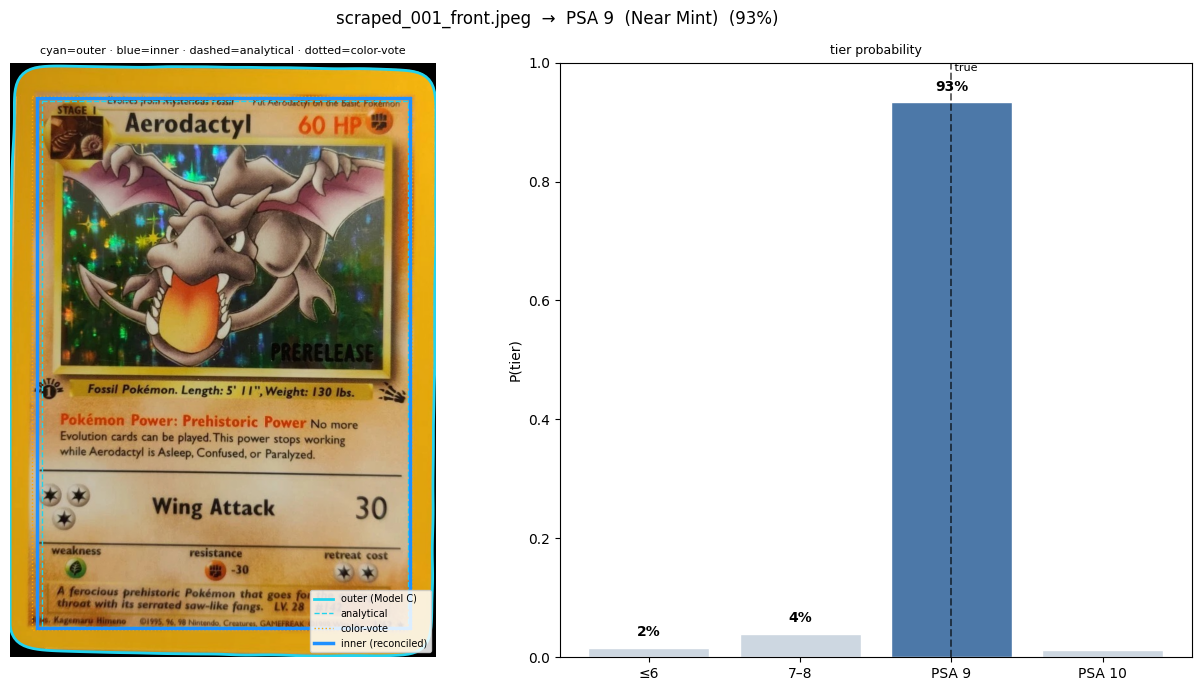

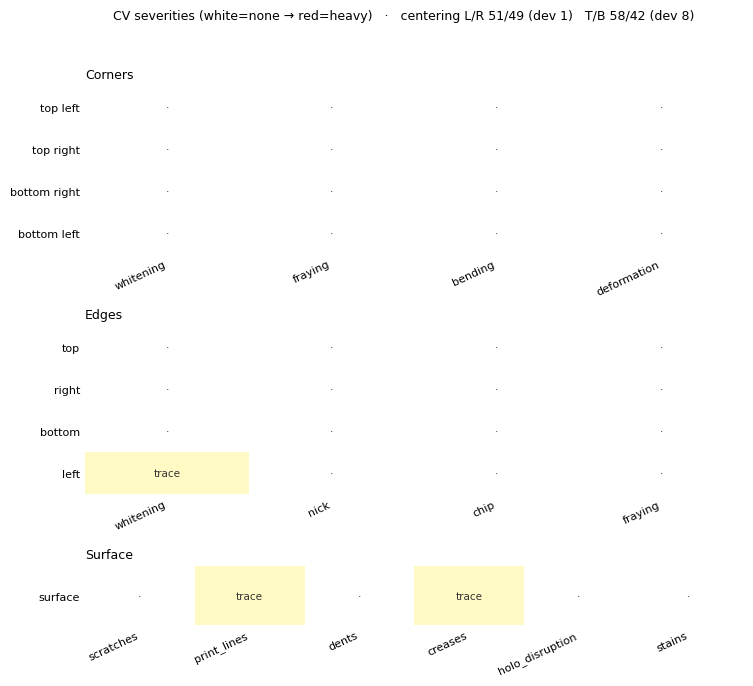

── Haiku model ──
scraped_001_front.jpeg
  centering  L/R 51/49  T/B 58/42  score 9/10  border dragon  reliable True
  detector seg  seg_conf 71%
  PREDICTION → Don't grade  (≤6)   (48%)  (true PSA 9)   [model: haiku]


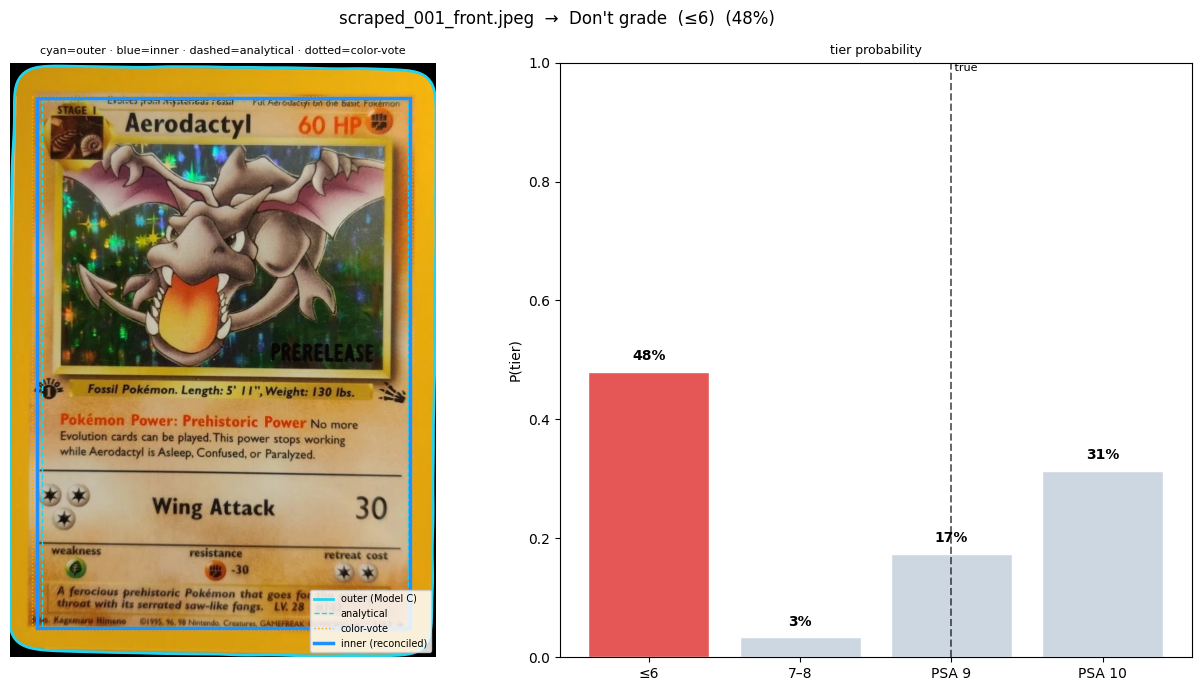

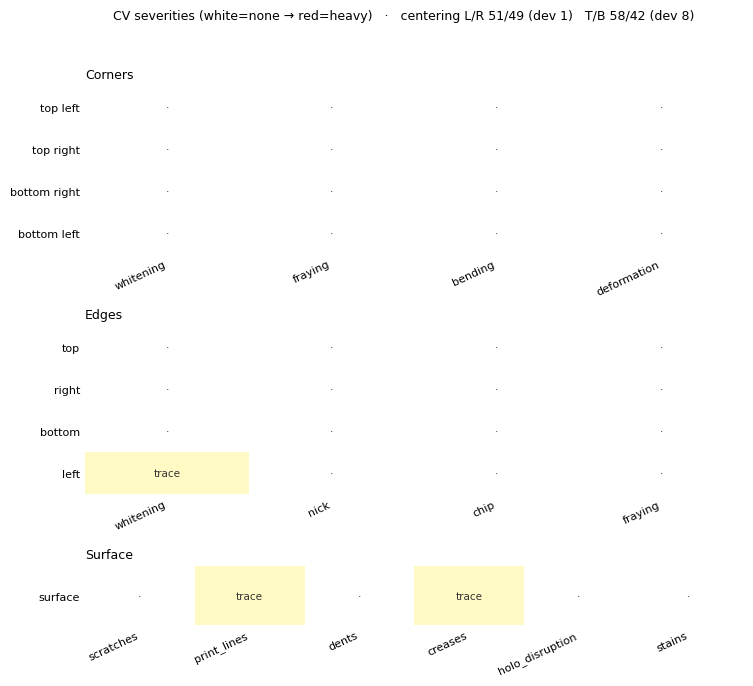

In [5]:
CARD     = str(BASE/'9'/'scraped_001_front.jpeg')   # ← change me
TRUE_PSA = 9                                         # ← true grade

print('── CV model ──')
resp = cv_pred.show(CARD, true_psa=TRUE_PSA)
print('── Haiku model ──')
resp = haiku_pred.show(CARD, true_psa=TRUE_PSA)

## § Batch prediction

In [6]:
paths     = [p for p,g in examples.values()]
true_psas = [g for p,g in examples.values()]
cv_df    = cv_pred.predict_batch(paths, psa_grades=true_psas)
haiku_df = haiku_pred.predict_batch(paths, psa_grades=true_psas)
cv_df['model']='CV'; haiku_df['model']='Haiku'
combined = pd.concat([cv_df,haiku_df],ignore_index=True)
display(combined[['model','file','true_psa','tier','confidence','recommendation']]
        .sort_values(['file','model']).reset_index(drop=True))

,model,file,true_psa,tier,confidence,recommendation
0,CV,scraped_001_front.jpeg,5,Don't grade (≤6),0.965,Don't submit — not worth the fee
1,CV,scraped_001_front.jpeg,7,Consider (7–8),0.971,Consider — depends on card value
2,CV,scraped_001_front.jpeg,9,PSA 9 (Near Mint),0.933,Submit — PSA 9 adds significant value
3,CV,scraped_001_front.jpeg,10,PSA 10 (Gem Mint),0.950,"Submit — PSA 10 Gem Mint, max premium"
4,Haiku,scraped_001_front.jpeg,5,Don't grade (≤6),0.581,Don't submit — not worth the fee
5,Haiku,scraped_001_front.jpeg,7,Consider (7–8),0.893,Consider — depends on card value
6,Haiku,scraped_001_front.jpeg,9,PSA 9 (Near Mint),0.659,Submit — PSA 9 adds significant value
7,Haiku,scraped_001_front.jpeg,10,PSA 9 (Near Mint),0.382,Submit — PSA 9 adds significant value


---
## § New-card test harness — `NewCardTest`

One class for the whole loop, so you never scroll between cells:

```python
t = NewCardTest()                       # raw model (best, 43.4% exact); NewCardTest(model="processed") for the 39.3% one
t.select(grade=7)                       # pick a random PSA-7 card   (or select(card="/path.jpeg", grade=7))
t.predict()                             # quick tier + recommendation
t.report()                              # FULL: prediction + boundaries + bars + feature table + L/R, T/B, reliability
t.panel()                               # ★ CLICKABLE card + heatmap grid + zoom (click a cell → highlight + magnify)
t.manual()                              # interactive sliders → live re-prediction
t.verify()                              # overlay detections ON the pixels (spot foil false positives)
t.magnify()                             # interactive loupe: pan/zoom to validate any finding
t.set_borders(L=4, R=4, T=3, B=3)       # non-interactive border override → re-extract → re-predict → render
t.run(grade=7)                          # = select + report in one shot
```
`select()` sets the current card; every other method operates on it.

In [23]:
# ── NewCardTest — single harness for the new-card testing pipeline ──────────
import glob, time, importlib
import numpy as np
import nonvlm_cv as N; importlib.reload(N)

class NewCardTest:
    """select → predict → report (grades+diagnostics) → manual / set_borders (rerun).

        t = NewCardTest()
        t.select(grade=7)                 # or select(card="/path.jpeg", grade=7)
        t.predict()                       # quick tier + recommendation
        t.report()                        # full diagnostics (one shot)
        t.manual()                        # interactive slider correction → live re-predict
        t.set_borders(L=4,R=4,T=3,B=3)    # typed border override → re-predict + render
        t.run(grade=7)                    # = select + report
    """
    NEWCARD_CSV = BASE / "cv_features_newcard.csv"
    MODELS_BY_KIND = {"raw": "cv_xgb_raw.pkl", "processed": "cv_xgb_processed.pkl"}

    def __init__(self, model="raw", model_path=None, detector="seg"):
        # model="raw" (best, 43.4% exact) | "processed" (39.3%) | or pass model_path
        path = model_path or (MODELS / self.MODELS_BY_KIND.get(model, "cv_xgb_raw.pkl"))
        self.gp = GradePredictor(str(path), feature_source="cv", detector=detector)
        self.card = None; self.grade = None; self.result = None

    # ---- card selection -----------------------------------------------------
    def _get_card(self, grade=7):
        pats = [f"/Users/srinivasdoddi/srini/card-solutoin-testing/datasets/psa_graded/backup2/{grade}/ex*front*.jpeg",
                f"./datasets/psa/{grade}/*.jpg",
                f"feature_extraction_dataset/{grade}/*_front.jpeg"]
        for p in pats[1:2]:
            fs = glob.glob(p)
            if fs: np.random.shuffle(fs); return fs[0]
        raise FileNotFoundError(f"No card found for grade {grade}")

    def select(self, card=None, grade=7):
        self.card = card or self._get_card(grade); self.grade = grade
        print(f"selected → {os.path.basename(self.card)}   (grade {grade})")
        return self

    def _need(self):
        if not self.card:
            raise RuntimeError("No card selected — call .select(card=...) or .select(grade=...) first.")

    # ---- prediction & diagnostics ------------------------------------------
    def predict(self):
        self._need(); r = self.gp.predict(self.card)
        print(f"{os.path.basename(self.card)} → {r['tier']}  ({r['confidence']:.0%})   {r['recommendation']}")
        return r

    def _save_csv(self, r):
        cen=r["cen"]; lr=int(cen["left_right"].split("/")[0]); tb=int(cen["top_bottom"].split("/")[0])
        vec=N.features_to_vector(r["cv_cond"])
        row={"file":os.path.basename(self.card),"actual_psa":self.grade,"path":os.path.abspath(self.card),
             "cen.lr_deviation":abs(lr-50),"cen.tb_deviation":abs(tb-50),
             **{f"cv.{k}":v for k,v in vec.items()}}
        pd.DataFrame([row]).to_csv(str(self.NEWCARD_CSV), index=False)

    def report(self, cr=None, det=None):
        """Full one-shot: prediction + boundaries + bars + feature table + details."""
        self._need()
        self.result = self.gp.analyze(self.card, cr=cr, det=det); self._save_csv(self.result)
        self.gp.render(self.result, true_psa=self.grade)
        return self.result

    def run(self, grade=7, card=None):
        return self.select(card=card, grade=grade).report()

    # ---- manual centering correction ---------------------------------------
    def manual(self):
        """Interactive: drag sliders to set the inner border → live re-prediction."""
        self._need(); return self.gp.manual(self.card, true_psa=self.grade)

    def verify(self):
        """Overlay detected defects ON the card pixels (spot full-art/foil false positives)."""
        self._need(); return self.gp.verify(self.card, true_psa=self.grade)

    def magnify(self):
        """Interactive loupe: pan/zoom into the card to validate findings against the pixels."""
        self._need(); return self.gp.magnify(self.card)

    def panel(self):
        """Clickable card + heatmap grid + zoom: click a cell → highlight region + magnify."""
        self._need(); return self.gp.panel(self.card, true_psa=self.grade)

    def set_borders(self, L, R, T, B):
        """Typed override: inner-border widths as % of card → re-extract → re-predict → render."""
        self._need()
        det = N.detect_and_warp(cv2.imread(self.card), detector=self.gp.detector, out_size=N.CV_WARP_SIZE)
        x1,y1,x2,y2 = det["cb"]; iw,ih = x2-x1, y2-y1
        cr = {"x1":x1+L/100*iw, "x2":x2-R/100*iw, "y1":y1+T/100*ih, "y2":y2-B/100*ih}
        return self.report(cr=cr, det=det)

print("NewCardTest ready → select · predict · report · manual · set_borders · run")

NewCardTest ready → select · predict · report · manual · set_borders · run


  model: RAW  source: cv  features: 190
selected → OxtzBwSJzkeM-VzuhoAgTg.jpg   (grade 10)
OxtzBwSJzkeM-VzuhoAgTg.jpg
  centering  L/R 44/56  T/B 47/53  score 9/10  border uniform_fallback  reliable True
  detector seg  seg_conf 81%
  PREDICTION → PSA 9  (Near Mint)   (67%)  (true PSA 10)   [model: raw]


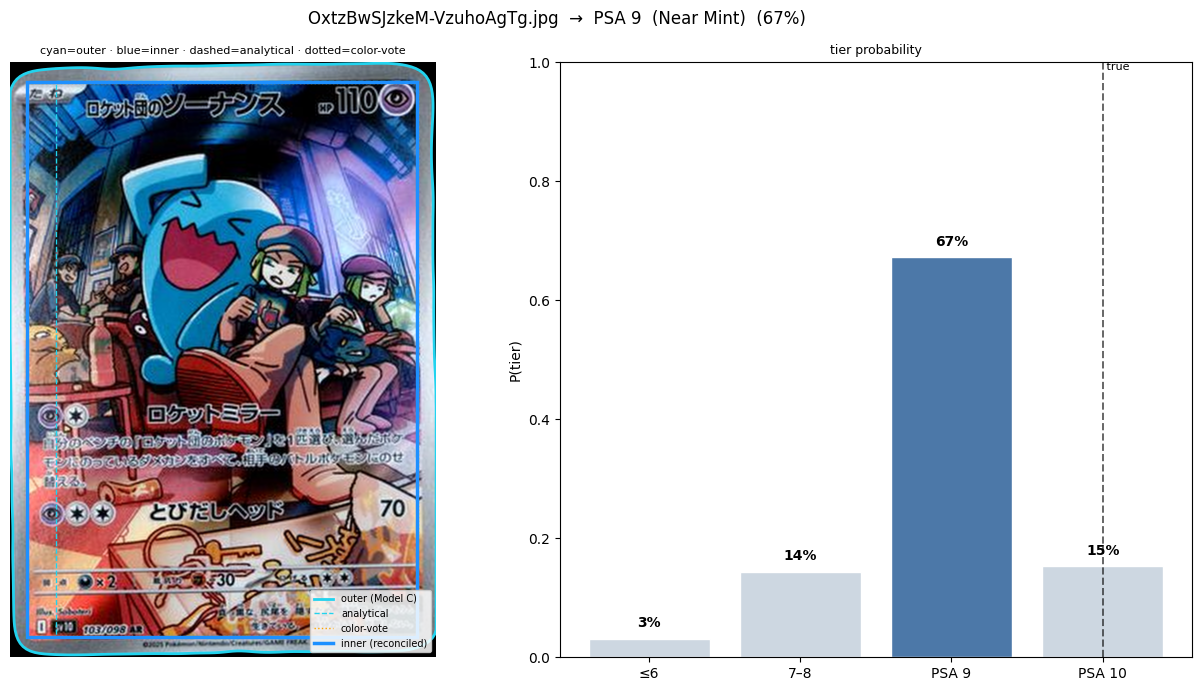

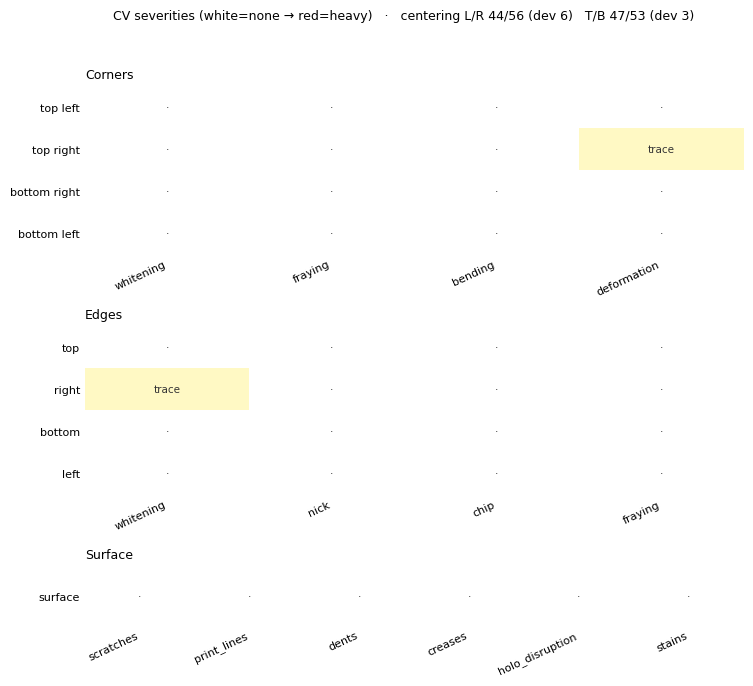

In [27]:
t = NewCardTest()
t.select(grade=10)         # or: t.select(card="/path/to/card.jpeg", grade=7)
resp = t.report()                # prediction + boundaries + bars + feature table + details

---
### ▶ Clickable inspector — `t.panel()`

Card + severity **heatmap grid** + zoom, all linked. **Click any heatmap cell** → it
highlights that region on the card (orange box) and **magnifies** it (red = edge/corner
whitening, cyan = scratch); the caption shows that cell's severity + raw magnitude.
Self-contained — run this cell directly.

In [29]:
# Clickable card + heatmap grid + zoom (click a cell → highlight region + magnify)
t = NewCardTest()            # raw model (best). NewCardTest(model="processed") to compare
t.select(grade=10)           # PSA-10 foil card shows the full-art fix; try other grades too
t.panel()

  model: RAW  source: cv  features: 190
selected → dTBb6Oy_00yBy6XQ8mmiMQ.jpg   (grade 10)


In [26]:
# Interactive: drag the L/R/T/B sliders → live re-prediction
t.manual()

In [11]:
# Or set the border widths by hand (no widgets) → re-extract + re-predict
#t.set_borders(L=20, R=4, T=3, B=3)